# Notebook 5: Value Function Parametric Approximation  

In this notebook, we will use an Artificial Neural Network to approximate a value function.

In [1]:
# Load dependencies
using Distributions
using Interpolations
using Expectations
using StatsPlots
using IterTools
using Surrogates
using Kronecker
using SparseArrays
using LinearAlgebra
using Flux
using ProgressMeter
using Plots

In [3]:
# Structural parameters
β   = 0.99    # discount rate
δ   = 0.025   # depreciation rate
α   = 0.36    # capital share
ρz  = 0.95    # persistence of technology 
σz  = 0.007   # unconditional SD of technology
μz  = 0.      # mean of technology
# Steady-state values
kstat = ((1-β*(1-δ))/(β*α))^(1/(α-1))
cstat = kstat^α - δ*kstat

In [7]:
# Technological shocks
ψ         = σz*sqrt(1.0-ρz^2)                # SD of the innovations
dist_ψ    = Normal(0,ψ)                      # dsitribution for the innovations
nb_nodes  = 5                                # number of nodes for expectations
E         = expectation(dist_ψ,n=nb_nodes)   # expectation operator
nodes_E   = nodes(E)                         # expectations nodes
weigths_E = weights(E);                      # expectations weights

In [13]:
# Discretization of the capital
k_low  = 0.8*kstat
k_high = 1.2*kstat
nk     = 101  #number of grid points
kprime_grid = collect(range(k_low,k_high,length=nk))
# Define an interval for technology (5th-95th percentiles)
dist_z = LogNormal(μz,σz)
P5 = quantile(dist_z, 0.05);P95 = quantile(dist_z, 0.95);

In [9]:
# Define some vectorized functions
u_kz  ::Function = x -> x[1,:].^α .* x[2,:] .+ (1-δ).*x[1,:]
u_k   ::Function = x -> - x[1,:]
u_kzk ::Function = (x,y) -> begin
    c = u_kz(x) + u_k(y)
    log.(clamp.(c, 1e-10, Inf))
end;

In [11]:
# Draw some points in the state space
n_samples_k = 10 # number of draws for the k dimension
n_samples_z = 5  # number of draws for the z dimension
n_states = n_samples_k * n_samples_z
lower_bound = [k_low, P5]
upper_bound = [k_high, P95]
k_grid = collect(range(lower_bound[1], upper_bound[1], length=n_samples_k))
z_grid = collect(range(lower_bound[2], upper_bound[2], length=n_samples_z))
nodes_kz = (k_grid, z_grid);

In [14]:
# Create some vectorized grids

# State grid (k, z) 
grid_1 = zeros(2, n_states)
index = 1
for (kValue, zValue) in product(k_grid, z_grid)
    grid_1[1, index] = kValue
    grid_1[2, index] = zValue
    index += 1
end

# Repeat each state column nk times (to evaluate for all controls)
grid_1_expanded = repeat(grid_1, inner=(1, nk))

# Control grid for each state
grid_controls = reshape(repeat(reshape(kprime_grid, 1, :),outer=(n_states, 1))',1,:)
  
# Next period (k', z') 
grid_2 = zeros(2, n_states*nk*nb_nodes)
index = 1
for state_idx in 1:n_states
    zValue = grid_1[2, state_idx]
    for kp in kprime_grid
        for innovation in nodes_E
            grid_2[1, index] = kp
            grid_2[2, index] = (zValue^ρz)*exp(innovation)
            index += 1
        end
    end
end

# Expectation matrix: average over all possible shocks
W = sparse(kronecker(Matrix(I, n_states*nk, n_states*nk), weigths_E));

In [15]:
# Define a function for the Bellman operator
function bellman_operator(model, grid_1_expanded, grid_controls, grid_2, W, nk, n_states)

    u_flow = u_kzk(grid_1_expanded, grid_controls)[:,:]'
    EV =reshape([model(grid_2[:,i]) for i in 1:size(grid_2,2)],1,:)* W
    total_value = u_flow .+ β .* EV
    total_reshaped = reshape(vec(total_value), nk, n_states)
    TV = vec(maximum(total_reshaped, dims=1))[:,:]'

    return TV
end;

In [16]:
# Solve the value function with VFI (benchmark)
V_old = zeros(1,n_samples_k*n_samples_z)
V_new = zeros(1,n_samples_k,n_samples_z)
# Define a function to interpolate the value function on points off grid
itp = interpolate(nodes_kz, reshape(V_old, n_samples_k, n_samples_z), Gridded(Linear()))
etp = extrapolate(itp, Line())
V_old_interpolated = (x) -> etp(x[1], x[2])

# Solve for the fixed point
max_iter = 5000
tol = 10^-8
@time begin
    for i = 1:max_iter

        V_new=bellman_operator(V_old_interpolated, grid_1_expanded, grid_controls, grid_2, W, nk, n_states)

        # distance
        diff = maximum(abs.(V_new .- V_old))
        if mod(i,50) == 0
            println("Iter $(i) Diff : $(diff)")
        end

        if diff < tol
            println("Iter $(i) Convergence reached")
            break
        end

        # update
        V_old = copy(V_new)

        # update the "model"
        itp = interpolate(nodes_kz, reshape(V_old, n_samples_k, n_samples_z), Gridded(Linear()))
        etp = extrapolate(itp, Line())
        V_old_interpolated = (x) -> etp(x[1], x[2])

    end
end;

Iter 50 Diff : 0.6078403572938029
Iter 100 Diff : 0.3653709582782483
Iter 150 Diff : 0.22072970039097584
Iter 200 Diff : 0.1335105994434258
Iter 250 Diff : 0.08077244723467913
Iter 300 Diff : 0.048867692077081415
Iter 350 Diff : 0.029565242720337892
Iter 400 Diff : 0.01788715078031089
Iter 450 Diff : 0.01082183471974929
Iter 500 Diff : 0.0065472756614752825
Iter 550 Diff : 0.003961141498336929
Iter 600 Diff : 0.0023965146393010173
Iter 650 Diff : 0.0014499058967629708
Iter 700 Diff : 0.0008772018643270485
Iter 750 Diff : 0.0005307124500291138
Iter 800 Diff : 0.00032108425217813874
Iter 850 Diff : 0.00019425792063998415
Iter 900 Diff : 0.00011752722058133713
Iter 950 Diff : 7.110468152404792e-5
Iter 1000 Diff : 4.301876371926028e-5
Iter 1050 Diff : 2.602661305672882e-5
Iter 1100 Diff : 1.574625881062275e-5
Iter 1150 Diff : 9.526582132934891e-6
Iter 1200 Diff : 5.763640004374793e-6
Iter 1250 Diff : 3.4870371763418007e-6
Iter 1300 Diff : 2.1096786610996787e-6
Iter 1350 Diff : 1.2763683940

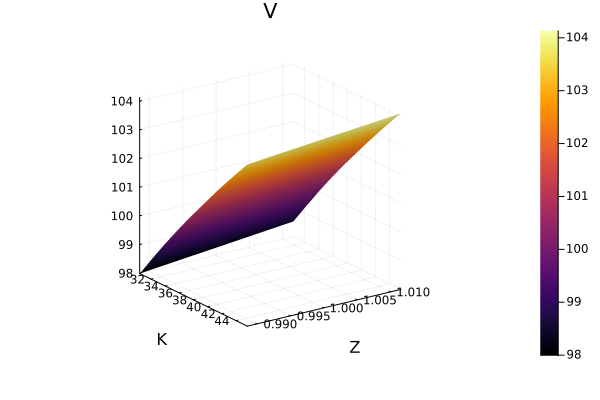

In [27]:
# Plot the results
V_old_=reshape(V_old,n_samples_k,n_samples_z) #vector2matrix
plot(k_grid, z_grid, (x, y) -> V_old_interpolated([x; y])[1], 
label = "f(x)", st=:surface,camera=(55, 20))
title!("V")
xlabel!("K")
ylabel!("Z")

In [47]:
# Some more grids to be used as a test set for the ANN
n_samples_test = n_samples_k * n_samples_z

# Test state grid (Sobol sampling)
grid_test_1 = zeros(2, n_samples_test)
index = 1
for (kValue, zValue) in Surrogates.sample(n_samples_test, [k_low, P5], [k_high, P95], SobolSample())
    grid_test_1[1, index] = kValue
    grid_test_1[2, index] = zValue
    index += 1
end

# Repeat each state column nk times (to evaluate for all controls)
grid_test_1_expanded = repeat(grid_test_1, inner=(1, nk))

# Control grid for each sampled state
grid_test_controls = reshape(repeat(reshape(kprime_grid, 1, :),outer=(n_samples_test, 1))',1,:)

# Next period states (k', z') 
grid_test_2 = zeros(2, n_samples_test*nk*nb_nodes)
index = 1
for state_idx in 1:n_samples_test
    zValue = grid_test_1[2, state_idx]
    for kp in kprime_grid
        for innovation in nodes_E
            grid_test_2[1, index] = kp
            grid_test_2[2, index] = (zValue^ρz)*exp(innovation)
            index += 1
        end
    end
end

# Expectation matrix
W_test = sparse(kronecker(Matrix(I, n_samples_test*nk, n_samples_test*nk), weigths_E));

In [32]:
# Redefine the bellman operator (for speed)
function bellman_operator_(model, grid_1_expanded, grid_controls, grid_2, W, nk, n_states)

    u_flow = u_kzk(grid_1_expanded, grid_controls)[:,:]'
    EV = model(grid_2) * W
    total_value = u_flow .+ β .* EV
    total_reshaped = reshape(vec(total_value), nk, n_states)
    TV = vec(maximum(total_reshaped, dims=1))[:,:]'

    return TV
end;

In [34]:
# Create ANN model (3 layers)
model = Chain(Dense(2, 300, relu),
              Dense(300, 100, relu),
              Dense(100, 10, relu),
              Dense(10, 1, identity))
ps = Flux.params(model)

# Check one pass of the gradient (should be fast enough)
@time begin
    gs = Flux.gradient( () -> Flux.Losses.mse( model(grid_1) - bellman_operator_(model, grid_1_expanded, grid_controls, grid_2, W, nk, n_states), y), ps)
end

  0.605134 seconds (459.17 k allocations: 1.170 GiB, 8.09% gc time, 60.28% compilation time)


Grads(...)

In [48]:
# Fit the model to our points
lr  = 0.01                     #learning rate
opt = Flux.Adam(lr)            #optimizer
epochs = 1000                  #number of time the model runs through the sample
trainingLosses = zeros(epochs) #track of the training progress
testLosses = zeros(epochs)     #test on data not used in the training

ps = Flux.params(model) #initialize weigths
p_bar = Progress(epochs; desc = "Training in progress"); # Creates a progress bar
showProgress = true

# Estimate the parameters
@time for ii in 1:epochs
    gs = Flux.gradient( () -> Flux.Losses.mse( model(grid_1) - bellman_operator_(model, grid_1_expanded, grid_controls, grid_2, W, nk, n_states), y), ps)
    Flux.Optimise.update!(opt, ps, gs) # update parameters
    if showProgress
        trainingLosses[ii] = Flux.Losses.mse( model(grid_1) - bellman_operator_(model, grid_1_expanded, grid_controls, grid_2, W, nk, n_states), y)
        testLosses[ii] = Flux.Losses.mse( model(grid_test_1) - bellman_operator_(model, grid_test_1_expanded, grid_test_controls, grid_test_2, W_test, nk, n_states), y)
        next!(p_bar; showvalues = [(:epochs, ii), (:logloss, log.(trainingLosses[ii])), (:loglosstest, log.(testLosses[ii]))], valuecolor = :grey)
    end
end

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/kVZZH/src/ProgressMeter.jl:594
Training in progress 100%|███████████████████████████████| Time: 0:03:31
  epochs:       1000
  logloss:      -9.466568033279518
  loglosstest:  -9.946480110576122


211.258208 seconds (6.11 M allocations: 1.273 TiB, 6.26% gc time, 0.49% compilation time: 2% of which was recompilation)


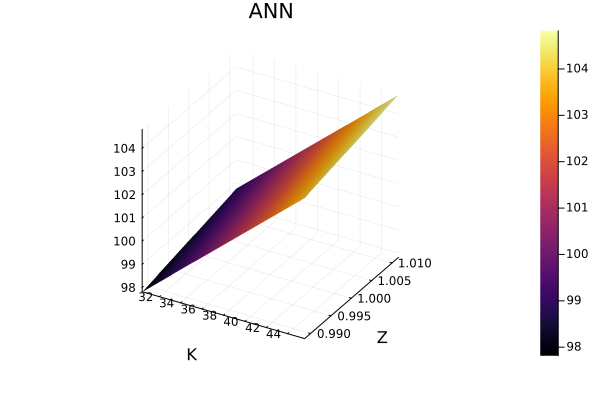

In [49]:
# Plot the result
plot(k_grid, z_grid, (x, y) -> model([x; y])[1], label = "f(x)", st=:surface)
title!("ANN")
xlabel!("K")
ylabel!("Z") #very similar to our VFI results

In [52]:
# Evaluate both methods on the test grid points
V_vfi_test = zeros(1, n_samples_test)
V_ann_test = zeros(1, n_samples_test)

for i in 1:n_samples_test
    k = grid_test_1[1, i]
    z = grid_test_1[2, i]
    V_vfi_test[1, i] = V_old_interpolated([k; z])
    V_ann_test[1, i] = model([k; z])[1]
end

V_diff_test = abs.(V_vfi_test - V_ann_test)

# Summary statistics
println("\n=== Comparison on Test Grid ===")
println("Maximum absolute difference: ", maximum(V_diff_test))
println("Mean absolute difference: ", mean(V_diff_test))
println("Median absolute difference: ", median(V_diff_test))
println("Max relative error: ", 100 * maximum(V_diff_test ./ V_vfi_test), "%")


=== Comparison on Test Grid ===
Maximum absolute difference: 0.5774490561086338
Mean absolute difference: 0.1730246354804501
Median absolute difference: 0.1451180493225266
Max relative error: 0.5561594022769748%


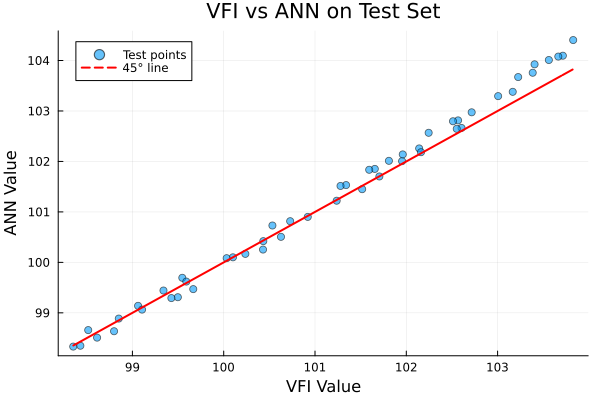

In [54]:
# Plot difference along the vectorized state
scatter(vec(V_vfi_test), vec(V_ann_test),
xlabel="VFI Value", ylabel="ANN Value",
title="VFI vs ANN on Test Set",
label="Test points", alpha=0.6)
plot!(vec(V_vfi_test), vec(V_vfi_test),
label="45° line", linestyle=:dash, linewidth=2, color=:red,legend=:topleft)

### Takeaways:
There is no real gain (quite the opposite) from using an ANN in this context. However, there is considerable active research in this area showing that ML methods can in fact be useful for solving value functions, especially for large state spaces.